# Coverage and canonical 4-mer profiles for selected bin-neighbour cases

This notebook analyses the two graph-view cases supplied separately as PDFs. The PDFs are used only to identify the visible coloured neighbour sets; all plotted values are recomputed from `tests/data`.

- Sim-5G: target `NODE_232`, coloured binned neighbours `NODE_70`, `NODE_145`, `NODE_243`
- Sim-10G: target `NODE_338`, coloured binned neighbours `NODE_73`, `NODE_87`, `NODE_26`, `NODE_24`

4-mer counts are normalised within each contig and reverse complements are combined by assigning each 4-mer to its canonical form.

In [1]:
from __future__ import annotations

import itertools
import os
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
os.environ.setdefault("MPLCONFIGDIR", str(REPO_ROOT / ".cache" / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 20)

DATA_ROOT = REPO_ROOT / "tests" / "data"
FIGURE_DIR = REPO_ROOT / "images"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DNA_ALPHABET = "ACGT"
DNA_COMPLEMENT = str.maketrans("ACGT", "TGCA")
K = 4

CASE_CONFIGS = [
    {
        "dataset": "Sim-5G",
        "target": "NODE_232",
        "neighbours": ["NODE_70", "NODE_145", "NODE_243"],
        "bin_colours": {"bin_0": "#2c7fb8", "bin_5": "#9467bd"},
        "node_colours": {"NODE_232": "#2c7fb8", "NODE_70": "#9467bd", "NODE_145": "#9467bd", "NODE_243": "#9467bd"},
    },
    {
        "dataset": "Sim-10G",
        "target": "NODE_338",
        "neighbours": ["NODE_73", "NODE_87", "NODE_26", "NODE_24"],
        "bin_colours": {"bin_12": "#2ca02c", "bin_8": "#20b8c7"},
        "node_colours": {"NODE_338": "#2ca02c", "NODE_73": "#20b8c7", "NODE_87": "#20b8c7", "NODE_26": "#20b8c7", "NODE_24": "#20b8c7"},
    },
]


def figure_stem(case: dict[str, object], suffix: str) -> str:
    dataset = str(case["dataset"]).lower().replace("-", "_")
    target = str(case["target"]).lower()
    return f"{dataset}_{target}_{suffix}"

In [2]:
SPADES_CONTIG_RE = re.compile(
    r"^(?P<short>NODE_(?P<node_id>\d+))_length_(?P<length>\d+)_cov_(?P<coverage>[0-9.eE+-]+)"
)


def clean_contig_name(name: object) -> str:
    text = str(name).strip()
    if text.startswith(">"):
        text = text[1:]
    return text.split()[0].rstrip("'")


def contig_short_name(name: object) -> str:
    text = clean_contig_name(name)
    match = SPADES_CONTIG_RE.match(text)
    if match:
        return match.group("short")
    short_match = re.match(r"^(NODE_\d+)", text)
    return short_match.group(1) if short_match else text


def parse_spades_contig_name(name: object) -> dict[str, object]:
    text = clean_contig_name(name)
    match = SPADES_CONTIG_RE.match(text)
    if not match:
        return {"contig": text, "contig_short": contig_short_name(text), "length": np.nan, "coverage": np.nan}
    return {
        "contig": text,
        "contig_short": match.group("short"),
        "length": int(match.group("length")),
        "coverage": float(match.group("coverage")),
    }


def read_fasta(path: Path) -> dict[str, str]:
    records = {}
    current = None
    chunks = []
    with path.open() as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if current is not None:
                    records[current] = "".join(chunks).upper()
                current = clean_contig_name(line)
                chunks = []
            else:
                chunks.append(line)
        if current is not None:
            records[current] = "".join(chunks).upper()
    return records


def read_two_column_table(path: Path, value_name: str) -> pd.DataFrame:
    frame = pd.read_csv(path, header=None, names=["contig", value_name])
    frame["contig"] = frame["contig"].map(clean_contig_name)
    frame["contig_short"] = frame["contig"].map(contig_short_name)
    return frame


def reverse_complement(kmer: str) -> str:
    return kmer.translate(DNA_COMPLEMENT)[::-1]


def canonical_kmer(kmer: str) -> str:
    return min(kmer, reverse_complement(kmer))


def canonical_kmers(k: int = K) -> list[str]:
    return sorted({canonical_kmer("".join(chars)) for chars in itertools.product(DNA_ALPHABET, repeat=k)})


CANONICAL_4MERS = canonical_kmers(K)
len(CANONICAL_4MERS)

136

In [3]:
def normalised_canonical_kmer_profile(sequence: str, k: int = K) -> dict[str, float]:
    counts = Counter()
    valid_windows = 0
    for idx in range(max(0, len(sequence) - k + 1)):
        kmer = sequence[idx : idx + k]
        if set(kmer).issubset(DNA_ALPHABET):
            counts[canonical_kmer(kmer)] += 1
            valid_windows += 1
    if valid_windows == 0:
        return {kmer: 0.0 for kmer in CANONICAL_4MERS}
    return {kmer: counts[kmer] / valid_windows for kmer in CANONICAL_4MERS}


def load_case_table(dataset: str, selected_short_names: list[str]) -> pd.DataFrame:
    dataset_dir = DATA_ROOT / dataset
    sequences = read_fasta(dataset_dir / "contigs.fasta")
    bins = read_two_column_table(dataset_dir / "initial_contig_bins.csv", "bin")
    truth = read_two_column_table(dataset_dir / "ground_truth.csv", "genome")

    records = []
    for contig, sequence in sequences.items():
        parsed = parse_spades_contig_name(contig)
        if parsed["contig_short"] not in selected_short_names:
            continue
        record = {**parsed, "sequence": sequence, "sequence_length": len(sequence)}
        record.update(normalised_canonical_kmer_profile(sequence))
        records.append(record)

    frame = pd.DataFrame.from_records(records)
    frame = frame.merge(bins[["contig_short", "bin"]], on="contig_short", how="left")
    frame = frame.merge(truth[["contig_short", "genome"]], on="contig_short", how="left")
    return frame


case_tables = {}
for case in CASE_CONFIGS:
    selected = [case["target"], *case["neighbours"]]
    table = load_case_table(case["dataset"], selected)
    missing = sorted(set(selected) - set(table["contig_short"]))
    if missing:
        raise ValueError(f"Missing contigs in {case['dataset']}: {missing}")
    table["role"] = np.where(table["contig_short"].eq(case["target"]), "target", "coloured neighbour")
    table["plot_order"] = table["contig_short"].map({name: idx for idx, name in enumerate(selected)})
    table = table.sort_values("plot_order")
    case_tables[case["dataset"]] = table

pd.concat(case_tables, names=["dataset", "row"]).reset_index(level=0).reset_index(drop=True)[[
    "dataset", "role", "contig_short", "coverage", "length", "bin", "genome"
]]

,dataset,role,contig_short,coverage,length,bin,genome
0,Sim-5G,target,NODE_232,183.804273,1506,bin_0,Acetobacter_pasteurianus
1,Sim-5G,coloured neighbour,NODE_70,93.748652,124468,bin_5,Acetobacter_pasteurianus
2,Sim-5G,coloured neighbour,NODE_145,89.375609,20784,bin_5,Acetobacter_pasteurianus
3,Sim-5G,coloured neighbour,NODE_243,82.462222,1295,bin_5,Acetobacter_pasteurianus
4,Sim-10G,target,NODE_338,49.259004,2526,bin_12,Bifidobacterium_adolescentis
5,Sim-10G,coloured neighbour,NODE_73,16.493803,169892,bin_8,Bifidobacterium_adolescentis
6,Sim-10G,coloured neighbour,NODE_87,16.413116,145174,bin_8,Bifidobacterium_adolescentis
7,Sim-10G,coloured neighbour,NODE_26,16.569268,425357,bin_8,Bifidobacterium_adolescentis
8,Sim-10G,coloured neighbour,NODE_24,16.521367,452343,bin_8,Bifidobacterium_adolescentis


## Coverage profiles

Coverage is parsed from the SPAdes contig names. Bars are coloured by assigned bin, with a black outline on the target contig in each case.

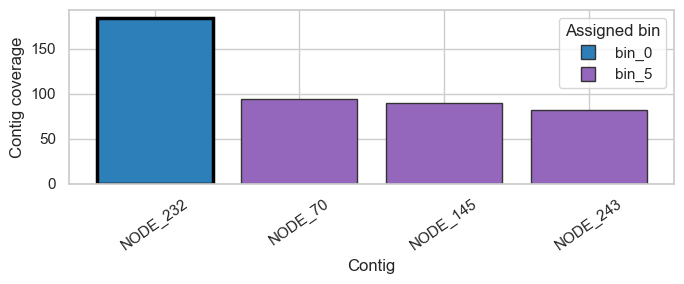

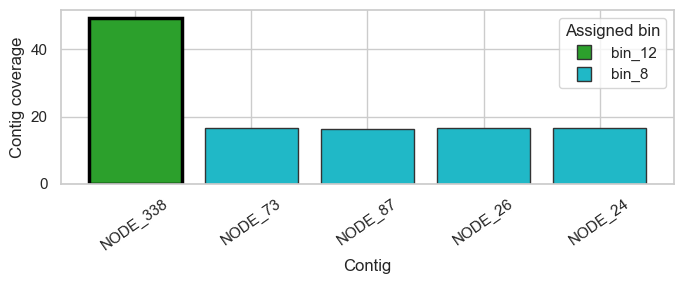

In [4]:
def plot_coverage(case: dict[str, object], table: pd.DataFrame) -> None:
    palette = {str(bin_id): colour for bin_id, colour in case.get("bin_colours", {}).items()}
    node_palette = {str(contig): colour for contig, colour in case.get("node_colours", {}).items()}
    colours = [node_palette.get(str(contig), palette.get(str(bin_id), "#d0d0d0")) for contig, bin_id in zip(table["contig_short"], table["bin"].fillna("unbinned"))]

    fig, ax = plt.subplots(figsize=(7, 3))
    bars = ax.bar(table["contig_short"], table["coverage"], color=colours, edgecolor="#333333", linewidth=1.0)
    for bar, role in zip(bars, table["role"]):
        if role == "target":
            bar.set_edgecolor("black")
            bar.set_linewidth(2.5)

    # ax.set_title(f"{case['dataset']} coverage: {case['target']} and coloured binned neighbours")
    ax.set_xlabel("Contig")
    ax.set_ylabel("Contig coverage")
    ax.tick_params(axis="x", rotation=35)

    handles = [plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=colour, markeredgecolor="#333333", markersize=10, label=bin_id) for bin_id, colour in palette.items()]
    ax.legend(handles=handles, title="Assigned bin", frameon=True, loc="best")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / f"{figure_stem(case, 'coverage')}.pdf", bbox_inches="tight")
    plt.show()


for case in CASE_CONFIGS:
    plot_coverage(case, case_tables[case["dataset"]])

## Normalised reverse-complement-combined 4-mer profiles

Each line is a contig profile over the 136 canonical 4-mers. Counts are divided by the number of valid 4-mer windows in that contig, so profiles are comparable across contig lengths.

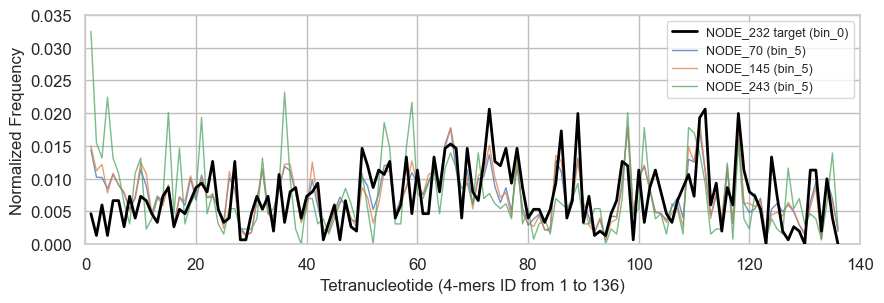

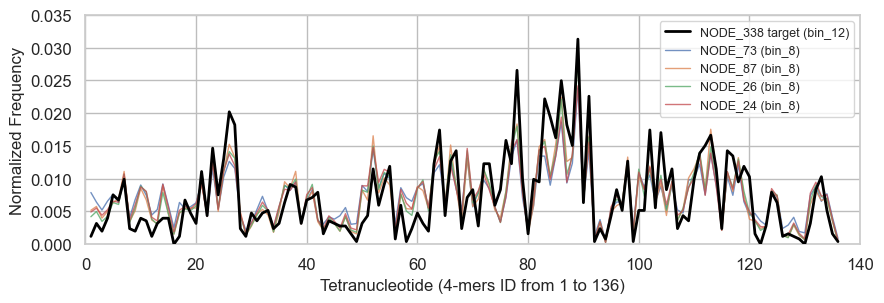

In [5]:
def format_tetranucleotide_axis(ax: plt.Axes) -> None:
    """Match Fig. 4(a): numeric tetranucleotide IDs on the x-axis."""
    ax.set_xlim(0, 140)
    ax.set_xticks(np.arange(0, 141, 20))
    ax.set_xlabel("Tetranucleotide (4-mers ID from 1 to 136)")
    ax.grid(True, which="major", axis="both", color="#bdbdbd", linewidth=1.0)


all_kmer_values = pd.concat([table[CANONICAL_4MERS] for table in case_tables.values()]).to_numpy(dtype=float)
kmer_ymax = float(np.nanmax(all_kmer_values))
KMER_YTICK_STEP = 0.005
KMER_YLIM = (0.0, np.ceil(kmer_ymax / KMER_YTICK_STEP) * KMER_YTICK_STEP)
KMER_YTICKS = np.arange(KMER_YLIM[0], KMER_YLIM[1] + KMER_YTICK_STEP / 2, KMER_YTICK_STEP)


def plot_kmer_lines(case: dict[str, object], table: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(9, 3.2))
    x = np.arange(1, len(CANONICAL_4MERS) + 1)
    for _, row in table.iterrows():
        values = row[CANONICAL_4MERS].to_numpy(dtype=float)
        if row["role"] == "target":
            ax.plot(x, values, color="black", linewidth=2, label=f"{row['contig_short']} target ({row['bin']})", zorder=3)
        else:
            ax.plot(x, values, linewidth=1, alpha=0.78, label=f"{row['contig_short']} ({row['bin']})")

    # ax.set_title(f"{case['dataset']} Tetranucleotide Distributions")
    ax.set_ylabel("Normalized Frequency")
    ax.set_ylim(KMER_YLIM)
    ax.set_yticks(KMER_YTICKS)
    format_tetranucleotide_axis(ax)
    ax.legend(ncol=2, frameon=True)
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=9)
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / f"{figure_stem(case, '4mer_profiles')}.pdf", bbox_inches="tight")
    plt.show()


for case in CASE_CONFIGS:
    plot_kmer_lines(case, case_tables[case["dataset"]])